# Cetacean Detection — Model vs Expert Comparison (Harrapatu, **5-second clip level**)

Compares model predictions against expert annotations, evaluating at the
**5-second clip** resolution (not collapsed to WAV/interval level).

### Expert annotations
`expert_detections.csv` contains only **positive rows** (T. truncatus = SI) at the
5-minute WAV / interval level. All intervals absent from that CSV are expert-negative.
The expert only labelled *Tursiops truncatus*, so evaluation is at the
**cetacean-detection level**, not per-species. Join key is the `YYMMDDHHMMSS`
timestamp token (position 1 in the dotted filename).

### Five decoding variants (same MLP logits, different post-hoc decoding)
| Variant | How it decides the clip label |
|---|---|
| `argmax`     | plain softmax argmax |
| `vec`        | per-class `w·logit + b`, inv-freq weighted |
| `pr`         | argmax among species clearing F1-optimal threshold, else background |
| `consensus3` | all three (argmax/vec/pr) agree → that label, else `uncertain` |
| `consensus2` | ≥2 of the three agree on a label → that label, else `uncertain` |

For each variant a clip is a **detection** if its label is not `background` /
`uncertain`. `uncertain` (from the consensus variants) is treated as non-detection.

### TP / FP / TN / FN definition (the important part)
The unit counted is the **5-second clip**, but TP vs FN is gated at the
interval (5-min WAV) level, because an expert "detection" on a 5-min file does
**not** mean signal is present throughout the file:

**Expert-positive interval** (expert annotated the WAV as a detection)
- if **≥1 clip fires** → interval is *caught*. Firing clips → **TP**,
  non-firing clips → **TN** (signal isn't everywhere in the file).
- if **0 clips fire** → interval is *missed*. Every clip → **FN**.

**Expert-negative interval** (no expert detection)
- firing clip → **FP**
- non-firing clip → **TN**

Consequence: FN only ever appears inside a fully-missed positive interval —
consistent with *"≥1 detection in the WAV ⇒ true positive."*

All five variants are evaluated independently under this same rule.

In [1]:
# ── 0. Imports & paths ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import re
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── EDIT THESE ───────────────────────────────────────────────────────────────
MY_PREDICTIONS_CSV = r"/data2/mromaniuc/cet-det/inference/inference_harrapatu/predictions/harrapatu_predictions_l4.csv"
EXPERT_CSV         = r"/data2/mromaniuc/cet-det/inference/inference_harrapatu/comparison/expert_detections.csv"
SPECTROGRAM_DIR    = r"/data2/mromaniuc/cet-det/inference/inference_harrapatu/spectrograms"
OUTPUT_CSV         = "harrapatu_comparison_5sec_v1.csv"           # per-variant clip-level summary
SEGMENT_OUTPUT_CSV = "harrapatu_comparison_5sec_v1_segments.csv"  # per-clip inspector
# ─────────────────────────────────────────────────────────────────────────────

# The five decoding variants evaluated throughout the notebook.
VARIANTS = ['argmax', 'vec', 'pr', 'consensus3', 'consensus2']

def normalise_wav_name(x):
    """Return just 'XXXX.wav' from any path, Windows or POSIX, with cleanup."""
    if pd.isna(x):
        return None
    s = str(x).strip().strip('"').strip("'")
    s = s.replace('\\\\', '/').replace('\\', '/')
    s = s.split('/')[-1]
    s = s.strip().lower()
    if not s.endswith('.wav'):
        s = s + '.wav'
    return s

def interval_from_wav(wav_name):
    """Extract the YYMMDDHHMMSS timestamp token (position 1 in dotted name).

    '9488.251007005000.wav' -> '251007005000'
    """
    if pd.isna(wav_name):
        return None
    base = normalise_wav_name(wav_name)
    parts = base.split('.')
    return parts[1] if len(parts) >= 2 else None

print("Config loaded.  Self-test of interval_from_wav:")
for t in ['9488.251007005000.wav', '6338.251010055958.wav',
          r'/datos/silvia/Harrapatu_2025/6338/6338.251010055958.wav']:
    print(f"  {t!r:60s} -> {interval_from_wav(t)!r}")

Config loaded.  Self-test of interval_from_wav:
  '9488.251007005000.wav'                                      -> '251007005000'
  '6338.251010055958.wav'                                      -> '251010055958'
  '/datos/silvia/Harrapatu_2025/6338/6338.251010055958.wav'    -> '251010055958'


In [2]:
# ── 1. Load model predictions & build the five variant labels ─────────────────
df_mine = pd.read_csv(MY_PREDICTIONS_CSV)
print(f"Raw CSV: {len(df_mine):,} rows, {df_mine.shape[1]} columns")

PATH_COL = next((c for c in ['wav_path', 'wav_name', 'file', 'filename', 'path']
                 if c in df_mine.columns), None)
assert PATH_COL is not None, f"No path column found. Columns: {list(df_mine.columns)}"
print(f"Using '{PATH_COL}' as the wav path column.")

df_mine['wav_name'] = df_mine[PATH_COL].apply(normalise_wav_name)
df_mine['interval'] = df_mine['wav_name'].map(interval_from_wav)
print(f"Example wav_name: {df_mine['wav_name'].iloc[0]!r}  interval: {df_mine['interval'].iloc[0]!r}")

# Rename prob columns to short codes
PROB_RENAME = {
    'prob_Balaenoptera_acutorostrata': 'prob_Ba',
    'prob_Balaenoptera_physalus':      'prob_Bp',
    'prob_Delphinidae_unknown':        'prob_Ambig',
    'prob_Delphinus_delphis':          'prob_Dd',
    'prob_Globicephala_melas':         'prob_Gm',
    'prob_Grampus_griseus':            'prob_Gg',
    'prob_Orcinus_orca':               'prob_Oo',
    'prob_Physeter_macrocephalus':     'prob_Pm',
    'prob_Stenella_coeruleoalba':      'prob_Sc',
    'prob_Tursiops_truncatus':         'prob_Tt',
    'prob_background':                 'prob_bg',
}
df_mine.rename(columns=PROB_RENAME, inplace=True)

CETACEAN_PROB_COLS = ['prob_Ba','prob_Bp','prob_Ambig','prob_Dd','prob_Gm',
                      'prob_Gg','prob_Oo','prob_Pm','prob_Sc','prob_Tt']
missing_probs = [c for c in CETACEAN_PROB_COLS + ['prob_bg'] if c not in df_mine.columns]
assert not missing_probs, f"Missing probability columns after rename: {missing_probs}"

BASE_STRATS = ['pred_argmax', 'pred_vec', 'pred_pr']
for col in BASE_STRATS:
    assert col in df_mine.columns, f"Strategy column '{col}' not in CSV."
    df_mine[col] = df_mine[col].astype(str).str.strip()

# Guard against duplicate (wav_name, segment_index)
if 'segment_index' in df_mine.columns:
    seg_dups = df_mine.duplicated(subset=['wav_name', 'segment_index']).sum()
    if seg_dups:
        print(f"  ⚠ {seg_dups} duplicate (wav_name, segment_index) — keeping first.")
        df_mine = df_mine.drop_duplicates(subset=['wav_name', 'segment_index'],
                                          keep='first').reset_index(drop=True)

# ── Build the two consensus labels per clip ───────────────────────────────────
# consensus3: all three agree -> that label, else 'uncertain'
# consensus2: a label held by >=2 of the three -> that label, else 'uncertain'
import collections

def consensus_labels(row):
    votes = [row['pred_argmax'], row['pred_vec'], row['pred_pr']]
    counts = collections.Counter(votes)
    label, n = counts.most_common(1)[0]
    cons3 = label if n == 3 else 'uncertain'
    cons2 = label if n >= 2 else 'uncertain'   # any majority of >=2 wins
    return pd.Series({'pred_consensus3': cons3, 'pred_consensus2': cons2})

df_mine[['pred_consensus3', 'pred_consensus2']] = df_mine.apply(consensus_labels, axis=1)

# Detection flag per variant: a clip "fires" if its label is a real cetacean
# species (not background, not uncertain).
NON_DETECTION = {'background', 'uncertain'}
for v in VARIANTS:
    df_mine[f'fired_{v}'] = ~df_mine[f'pred_{v}'].isin(NON_DETECTION)

df_mine['max_cetacean_prob'] = df_mine[CETACEAN_PROB_COLS].max(axis=1)

print(f"\nLoaded {len(df_mine):,} clips from {df_mine['wav_name'].nunique():,} WAV files "
      f"across {df_mine['interval'].nunique():,} unique 5-min intervals")
print("\nClip-level firing rate per variant:")
for v in VARIANTS:
    n = int(df_mine[f'fired_{v}'].sum())
    print(f"  {v:11s}: {n:,} firing clips ({100*n/len(df_mine):.1f}%)")
for v in ['consensus3', 'consensus2']:
    n_unc = int((df_mine[f'pred_{v}'] == 'uncertain').sum())
    print(f"  {v:11s}: {n_unc:,} 'uncertain' clips")

df_mine[['wav_name','interval','segment_index','offset_s',
         'pred_argmax','pred_vec','pred_pr','pred_consensus3','pred_consensus2']].head(5)

Raw CSV: 298,760 rows, 23 columns
Using 'wav_path' as the wav path column.
Example wav_name: '6338.251010055958.wav'  interval: '251010055958'

Loaded 298,760 clips from 6,359 WAV files across 4,079 unique 5-min intervals

Clip-level firing rate per variant:
  argmax     : 123,001 firing clips (41.2%)
  vec        : 153,073 firing clips (51.2%)
  pr         : 89,968 firing clips (30.1%)
  consensus3 : 89,965 firing clips (30.1%)
  consensus2 : 116,568 firing clips (39.0%)
  consensus3 : 63,837 'uncertain' clips
  consensus2 : 5,704 'uncertain' clips


,wav_name,interval,segment_index,offset_s,pred_argmax,pred_vec,pred_pr,pred_consensus3,pred_consensus2
0,6338.251010055958.wav,251010055958,0,0.0,background,background,background,background,background
1,6338.251010055958.wav,251010055958,1,5.0,background,background,background,background,background
2,6338.251010055958.wav,251010055958,2,10.0,background,background,background,background,background
3,6338.251010055958.wav,251010055958,3,15.0,background,background,background,background,background
4,6338.251010055958.wav,251010055958,4,20.0,background,background,background,background,background


In [3]:
# ── 2. Load expert annotations (positives only) ───────────────────────────────
# expert_detections.csv contains ONLY positive detections (T. truncatus = SI),
# at the 5-min interval level. One row per expert-positive interval (both
# hydrophones collapsed). Everything else is expert-negative.
df_exp_raw = pd.read_csv(EXPERT_CSV)
df_exp_raw['interval'] = df_exp_raw['interval'].astype(str)
print(f"Expert CSV: {len(df_exp_raw):,} rows")
print("  Format breakdown:")
print(df_exp_raw['format'].value_counts().to_string())
print(f"  Source files: {df_exp_raw['source_file'].nunique()} ({df_exp_raw['source_file'].unique()[:5].tolist()})")

df_expert = (
    df_exp_raw.groupby('interval', as_index=False)
    .agg(
        source_file  = ('source_file', lambda x: ', '.join(sorted(set(x)))),
        format       = ('format',      'first'),
        hydrophone   = ('hydrophone',  lambda x: ', '.join(sorted(set(x)))),
        date         = ('date',        'first'),
        n_hydrophone_detections = ('hydrophone', 'count'),
    )
)
df_expert['exp_positive'] = True   # every row in this table is expert-positive

dup_intervals = df_exp_raw['interval'].duplicated().sum()
if dup_intervals:
    print(f"  ℹ {dup_intervals} intervals had detections on both hydrophones — collapsed to one row each.")

print(f"\nUnique expert-positive intervals: {len(df_expert):,}")
df_expert[['interval','date','format','hydrophone','n_hydrophone_detections']].head()

Expert CSV: 316 rows
  Format breakdown:
format
interval_5min    161
segmented        155
  Source files: 8 (['Datos_L1.xlsx', 'Datos_L2.xlsx', 'Datos_L3.xlsx', 'Datos_L4.xlsx', 'Datos_L5.xlsx'])
  ℹ 7 intervals had detections on both hydrophones — collapsed to one row each.

Unique expert-positive intervals: 309


,interval,date,format,hydrophone,n_hydrophone_detections
0,250925190500,2025-09-25 19:05:00,segmented,H2,1
1,250926032500,2025-09-26 03:25:00,segmented,H2,1
2,250926045001,2025-09-26 04:50:01,segmented,H1,1
3,250926045501,2025-09-26 04:55:01,segmented,H1,1
4,250926050000,2025-09-26 05:00:00,segmented,H1,1


In [4]:
# ── 2b. Key-overlap diagnostic ────────────────────────────────────────────────
# The universe of intervals is defined by the model predictions (everything the
# model processed). Expert CSV has only positives.
mine_intervals = set(df_mine['interval'].dropna().unique())
exp_intervals  = set(df_expert['interval'].dropna().unique())

overlap     = mine_intervals & exp_intervals
only_expert = exp_intervals  - mine_intervals   # expert-positive, model never saw
only_model  = mine_intervals - exp_intervals    # model saw, expert found nothing

print(f"Model intervals       : {len(mine_intervals):,}")
print(f"Expert-positive       : {len(exp_intervals):,}")
print(f"Overlap (model saw + expert detected): {len(overlap):,}")
print(f"Expert-positive NOT in model          : {len(only_expert):,}")
print(f"  → these cannot be evaluated (model never processed them)")
print(f"Model intervals with no expert detection (negatives): {len(only_model):,}")

if len(overlap) == 0:
    print("\n❌ ZERO OVERLAP — the merge will be empty. Inspect sample keys:")
    print("  model :", sorted(mine_intervals)[:3])
    print("  expert:", sorted(exp_intervals)[:3])
else:
    print(f"\n✓ Overlap looks good. Sample matched intervals: {sorted(overlap)[:3]}")

Model intervals       : 4,079
Expert-positive       : 309
Overlap (model saw + expert detected): 247
Expert-positive NOT in model          : 62
  → these cannot be evaluated (model never processed them)
Model intervals with no expert detection (negatives): 3,832

✓ Overlap looks good. Sample matched intervals: ['250925190500', '250926032500', '250926045001']


In [5]:
# ── 3. Attach expert label to every clip + interval-level firing per variant ──
# Step 1: tag every clip with whether its interval is expert-positive.
# Step 2: for each variant, work out which intervals were "caught" (>=1 clip
#         fired) so we can apply the interval-gated TP/FN rule at clip level.

# Restrict to intervals the model actually processed (this already drops the
# expert-positives the model never saw — they aren't in df_mine).
clips = df_mine.copy()

exp_pos_set = set(df_expert['interval'])
clips['exp_positive'] = clips['interval'].isin(exp_pos_set)

# Bring along expert metadata (only meaningful for positive intervals)
clips = clips.merge(
    df_expert[['interval','date','format','hydrophone',
               'n_hydrophone_detections','source_file']],
    on='interval', how='left'
)

# For each variant, which intervals are "caught" = >=1 firing clip in interval
caught = {}   # variant -> set of intervals with at least one firing clip
for v in VARIANTS:
    fired_per_ivl = clips.groupby('interval')[f'fired_{v}'].any()
    caught[v] = set(fired_per_ivl[fired_per_ivl].index)

n_pos = clips['exp_positive'].sum()
print(f"Clips total            : {len(clips):,}")
print(f"  in expert-positive intervals: {int(n_pos):,}")
print(f"  in expert-negative intervals: {int((~clips['exp_positive']).sum()):,}")
print(f"Evaluable intervals    : {clips['interval'].nunique():,}")
print(f"  (expert-positives the model never processed, excluded: {len(only_expert)})")

print("\nExpert-positive intervals caught (>=1 firing clip) per variant:")
n_exp_pos_ivl = clips[clips['exp_positive']]['interval'].nunique()
for v in VARIANTS:
    caught_pos = len(caught[v] & exp_pos_set & mine_intervals)
    print(f"  {v:11s}: {caught_pos:,} / {n_exp_pos_ivl:,} positive intervals caught")

Clips total            : 298,760
  in expert-positive intervals: 19,552
  in expert-negative intervals: 279,208
Evaluable intervals    : 4,079
  (expert-positives the model never processed, excluded: 62)

Expert-positive intervals caught (>=1 firing clip) per variant:
  argmax     : 239 / 247 positive intervals caught
  vec        : 245 / 247 positive intervals caught
  pr         : 157 / 247 positive intervals caught
  consensus3 : 157 / 247 positive intervals caught
  consensus2 : 239 / 247 positive intervals caught


In [7]:
# ── 4. Clip-level TP / FP / TN / FN for each variant ──────────────────────────
# Rule (per clip), given its interval and whether that interval was "caught":
#
#   expert-positive interval:
#       caught (>=1 clip fired):  firing clip -> TP ; non-firing clip -> TN
#       missed (0 clips fired)  :  every clip -> FN
#   expert-negative interval:
#       firing clip -> FP ; non-firing clip -> TN
#
# This is fully vectorised per variant.

def clip_outcomes(clips, fired_col, exp_pos_col, caught_intervals):
    """Return a Series of 'TP'/'FP'/'TN'/'FN' for every clip under one variant."""
    fired   = clips[fired_col].to_numpy()
    exp_pos = clips[exp_pos_col].to_numpy()
    is_caught = clips['interval'].isin(caught_intervals).to_numpy()

    out = np.empty(len(clips), dtype=object)
    # expert-positive, interval caught
    m = exp_pos & is_caught
    out[m &  fired] = 'TP'
    out[m & ~fired] = 'TN'
    # expert-positive, interval missed (not caught -> by definition 0 fired)
    m = exp_pos & ~is_caught
    out[m] = 'FN'
    # expert-negative
    m = ~exp_pos
    out[m &  fired] = 'FP'
    out[m & ~fired] = 'TN'
    return pd.Series(out, index=clips.index)

def metrics_from_counts(TP, FP, TN, FN):
    recall      = TP / (TP + FN) if (TP + FN) else float('nan')
    precision   = TP / (TP + FP) if (TP + FP) else float('nan')
    specificity = TN / (TN + FP) if (TN + FP) else float('nan')
    f1 = (2*precision*recall / (precision+recall)
          if (precision and recall and not np.isnan(precision) and not np.isnan(recall))
          else float('nan'))
    accuracy = (TP + TN) / (TP + TN + FP + FN) if (TP+TN+FP+FN) else float('nan')
    return recall, precision, specificity, f1, accuracy

rows = []
for v in VARIANTS:
    oc = clip_outcomes(clips, f'fired_{v}', 'exp_positive', caught[v])
    clips[f'outcome_{v}'] = oc
    c = oc.value_counts()
    TP = int(c.get('TP', 0)); FP = int(c.get('FP', 0))
    TN = int(c.get('TN', 0)); FN = int(c.get('FN', 0))
    rc, pr, sp, f1, acc = metrics_from_counts(TP, FP, TN, FN)
    rows.append({'variant': v, 'TP': TP, 'FP': FP, 'TN': TN, 'FN': FN,
                 'recall': rc, 'precision': pr, 'specificity': sp,
                 'F1': f1, 'accuracy': acc})

clip_metrics = pd.DataFrame(rows).set_index('variant')

print("Clip-level (5-second) evaluation — all five variants\n")
print(clip_metrics.to_string(
    float_format=lambda x: f'{x:.3f}',
    formatters={'TP': '{:,}'.format, 'FP': '{:,}'.format,
                'TN': '{:,}'.format, 'FN': '{:,}'.format}))

clip_metrics.reset_index().to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved per-variant clip-level summary → {OUTPUT_CSV}")

Clip-level (5-second) evaluation — all five variants

              TP      FP      TN    FN  recall  precision  specificity    F1  accuracy
variant                                                                               
argmax     7,560 115,441 175,383   376   0.953      0.061        0.603 0.115     0.612
vec        9,332 143,741 145,593    94   0.990      0.061        0.503 0.115     0.519
pr         4,745  85,223 202,212 6,580   0.419      0.053        0.704 0.094     0.693
consensus3 4,745  85,220 202,215 6,580   0.419      0.053        0.704 0.094     0.693
consensus2 7,143 109,425 181,816   376   0.950      0.061        0.624 0.115     0.632

Saved per-variant clip-level summary → harrapatu_comparison_5sec_v1.csv


In [9]:
# ── 4c. Tursiops + Ambiguous-delphinid clip-level TP/FP/TN/FN per variant ─────
# HARRAPATU expert detections are Tursiops truncatus, but the model frequently
# routes genuine Tursiops-consistent delphinid activity to the ambiguous-
# delphinid class (Delphinidae_unknown / "Ambig") rather than to Tt directly.
# Here we count a clip as "fired" when its final label is EITHER Tursiops OR
# the ambiguous-delphinid class. Everything else is a non-detection.
#
# Interval gating + TP/FP/TN/FN rule identical to cell 4; only the "fired"
# definition changes, and the caught-interval set is recomputed accordingly.

TT_AMBIG_LABELS = {'Tursiops_truncatus', 'Tt', 'Delphinidae_unknown', 'Ambig'}

# Build a Tursiops+Ambig fired flag per variant
for v in VARIANTS:
    clips[f'fired_tta_{v}'] = clips[f'pred_{v}'].isin(TT_AMBIG_LABELS)

# Recompute "caught" intervals under this rule
caught_tta = {}
for v in VARIANTS:
    fired_by_ivl = clips.groupby('interval')[f'fired_tta_{v}'].any()
    caught_tta[v] = set(fired_by_ivl.index[fired_by_ivl.to_numpy()])

rows_tta = []
for v in VARIANTS:
    oc = clip_outcomes(clips, f'fired_tta_{v}', 'exp_positive', caught_tta[v])
    clips[f'outcome_tta_{v}'] = oc
    c = oc.value_counts()
    TP = int(c.get('TP', 0)); FP = int(c.get('FP', 0))
    TN = int(c.get('TN', 0)); FN = int(c.get('FN', 0))
    rc, pr, sp, f1, acc = metrics_from_counts(TP, FP, TN, FN)
    rows_tta.append({'variant': v, 'TP': TP, 'FP': FP, 'TN': TN, 'FN': FN,
                     'recall': rc, 'precision': pr, 'specificity': sp,
                     'F1': f1, 'accuracy': acc})

clip_metrics_tta = pd.DataFrame(rows_tta).set_index('variant')

print("Clip-level (5-second) evaluation — TURSIOPS + AMBIGUOUS-DELPHINID — all five variants\n")
print(clip_metrics_tta.to_string(
    float_format=lambda x: f'{x:.3f}',
    formatters={'TP': '{:,}'.format, 'FP': '{:,}'.format,
                'TN': '{:,}'.format, 'FN': '{:,}'.format}))

# Firing-clip counts across the three detection definitions, for comparison
print("\nFiring-clip counts:  Tursiops-only  |  Tt+Ambig  |  any-cetacean")
for v in VARIANTS:
    n_tt  = int(clips[f'fired_tt_{v}'].sum())  if f'fired_tt_{v}'  in clips else -1
    n_tta = int(clips[f'fired_tta_{v}'].sum())
    n_any = int(clips[f'fired_{v}'].sum())
    print(f"  {v:11s}: {n_tt:>8,}  |  {n_tta:>8,}  |  {n_any:>8,}")

TTA_OUTPUT_CSV = str(OUTPUT_CSV).replace('.csv', '_tursiops_ambig.csv')
clip_metrics_tta.reset_index().to_csv(TTA_OUTPUT_CSV, index=False)
print(f"\nSaved Tursiops+Ambig clip-level summary → {TTA_OUTPUT_CSV}")

Clip-level (5-second) evaluation — TURSIOPS + AMBIGUOUS-DELPHINID — all five variants

              TP      FP      TN    FN  recall  precision  specificity    F1  accuracy
variant                                                                               
argmax     7,070 109,054 181,978   658   0.915      0.061        0.625 0.114     0.633
vec        8,101 126,272 164,058   329   0.961      0.060        0.565 0.113     0.576
pr         4,721  84,958 202,125 6,956   0.404      0.053        0.704 0.093     0.692
consensus3 4,721  84,957 202,126 6,956   0.404      0.053        0.704 0.093     0.692
consensus2 6,744 104,362 186,996   658   0.911      0.061        0.642 0.114     0.648

Firing-clip counts:  Tursiops-only  |  Tt+Ambig  |  any-cetacean
  argmax     :   12,837  |   116,124  |   123,001
  vec        :    8,086  |   134,373  |   153,073
  pr         :      470  |    89,679  |    89,968
  consensus3 :      469  |    89,678  |    89,965
  consensus2 :    8,073  |   111,106  

In [7]:
# ── 5. Save per-clip inspector CSV ────────────────────────────────────────────
# One row per 5-second clip, with the label, fired flag and outcome for each of
# the five variants, plus probabilities and expert metadata.
SP_LONG_TO_SHORT = {k.replace('prob_', ''): v.replace('prob_', '')
                    for k, v in PROB_RENAME.items()}

def to_short(lbl):
    lbl = str(lbl)
    return SP_LONG_TO_SHORT.get(lbl, lbl)   # 'uncertain'/'background' pass through

seg = clips.copy()
seg['exp_cetacean_detected'] = seg['exp_positive']
seg['exp_top_species'] = np.where(seg['exp_positive'], 'Tt', 'background')

for v in VARIANTS:
    seg[f'pred_{v}'] = seg[f'pred_{v}'].map(to_short)

SEG_COLS = (
    ['wav_name', 'interval', 'segment_index', 'offset_s']
    + [f'pred_{v}' for v in VARIANTS]
    + [f'fired_{v}' for v in VARIANTS]
    + [f'outcome_{v}' for v in VARIANTS]
    + CETACEAN_PROB_COLS + ['prob_bg', 'max_cetacean_prob']
    + ['exp_positive', 'exp_cetacean_detected', 'exp_top_species']
    + ['date', 'format', 'hydrophone', 'source_file']
)
SEG_COLS = [c for c in SEG_COLS if c in seg.columns]
seg[SEG_COLS].to_csv(SEGMENT_OUTPUT_CSV, index=False)

print(f"Saved per-clip inspector CSV → {SEGMENT_OUTPUT_CSV}")
print(f"  {len(seg):,} clips, {seg['interval'].nunique():,} intervals")
print("\nClip-outcome distribution per variant:")
for v in VARIANTS:
    print(f"  {v:11s}: {seg[f'outcome_{v}'].value_counts().to_dict()}")
seg[SEG_COLS].head(3)

Saved per-clip inspector CSV → harrapatu_comparison_5sec_v1_segments.csv
  298,760 clips, 4,079 intervals

Clip-outcome distribution per variant:
  argmax     : {'TN': 175383, 'FP': 115441, 'TP': 7560, 'FN': 376}
  vec        : {'TN': 145593, 'FP': 143741, 'TP': 9332, 'FN': 94}
  pr         : {'TN': 202212, 'FP': 85223, 'FN': 6580, 'TP': 4745}
  consensus3 : {'TN': 202215, 'FP': 85220, 'FN': 6580, 'TP': 4745}
  consensus2 : {'TN': 181816, 'FP': 109425, 'TP': 7143, 'FN': 376}


,wav_name,interval,segment_index,offset_s,pred_argmax,pred_vec,pred_pr,pred_consensus3,pred_consensus2,fired_argmax,...,prob_Tt,prob_bg,max_cetacean_prob,exp_positive,exp_cetacean_detected,exp_top_species,date,format,hydrophone,source_file
0,6338.251010055958.wav,251010055958,0,0.0,bg,bg,bg,bg,bg,False,...,3.104397e-10,0.998145,0.001855,False,False,background,NaN,NaN,NaN,NaN
1,6338.251010055958.wav,251010055958,1,5.0,bg,bg,bg,bg,bg,False,...,9.168685e-07,0.993595,0.006404,False,False,background,NaN,NaN,NaN,NaN
2,6338.251010055958.wav,251010055958,2,10.0,bg,bg,bg,bg,bg,False,...,2.868804e-05,0.987018,0.012250,False,False,background,NaN,NaN,NaN,NaN


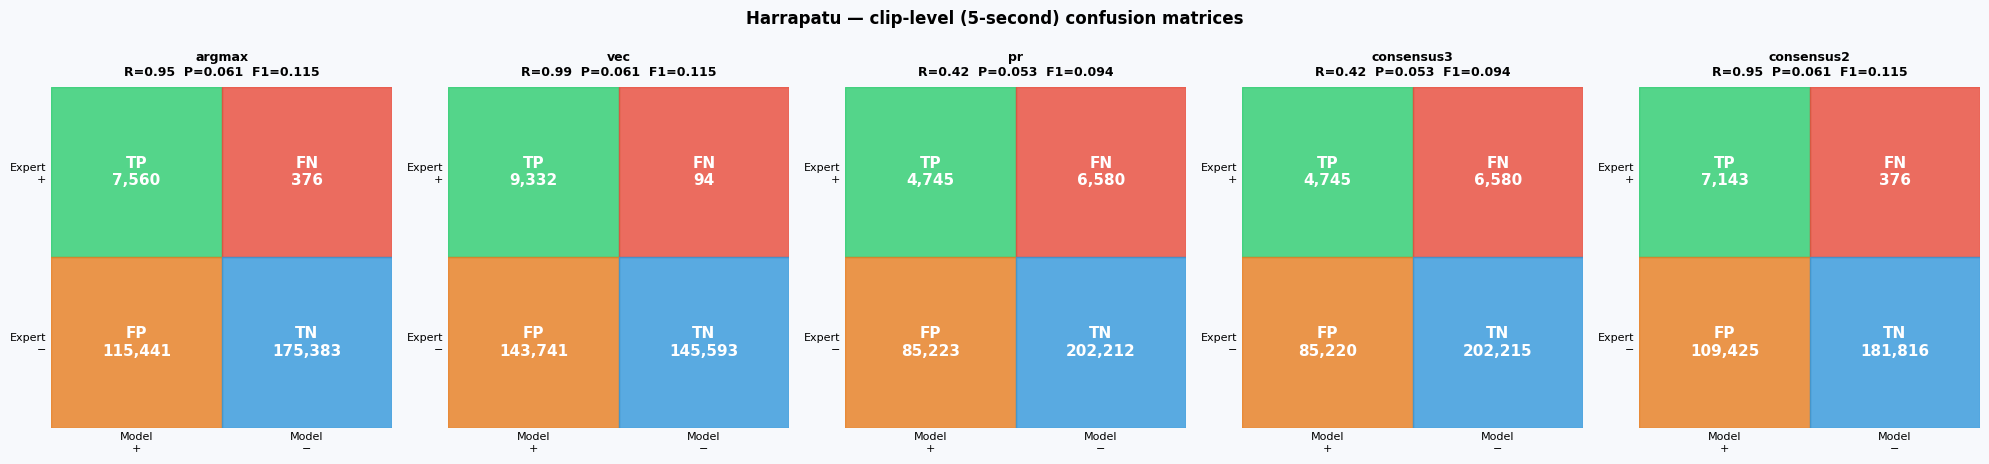

In [8]:
# ── B. Confusion matrices for all five variants ───────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(VARIANTS), figsize=(4*len(VARIANTS), 4.2))
fig.patch.set_facecolor('#f7f9fc')

for ax, v in zip(axes, VARIANTS):
    r = clip_metrics.loc[v]
    TP, FN, FP, TN = int(r['TP']), int(r['FN']), int(r['FP']), int(r['TN'])
    labels = [['TP', 'FN'], ['FP', 'TN']]
    counts = [[TP, FN], [FP, TN]]
    colors = [['#2ecc71', '#e74c3c'], ['#e67e22', '#3498db']]
    ax.set_xlim(0, 2); ax.set_ylim(0, 2); ax.set_aspect('equal')
    for rr in range(2):
        for cc in range(2):
            ax.add_patch(plt.Rectangle([cc, 1-rr], 1, 1, color=colors[rr][cc], alpha=0.82))
            ax.text(cc+0.5, 1.5-rr, f"{labels[rr][cc]}\n{counts[rr][cc]:,}",
                    ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    ax.set_xticks([0.5, 1.5]); ax.set_yticks([0.5, 1.5])
    ax.set_xticklabels(['Model\n+', 'Model\n−'], fontsize=8)
    ax.set_yticklabels(['Expert\n−', 'Expert\n+'], fontsize=8)
    ax.set_title(f"{v}\nR={r['recall']:.2f}  P={r['precision']:.3f}  F1={r['F1']:.3f}",
                 fontsize=9, fontweight='bold', pad=8)
    ax.tick_params(length=0)
    for spine in ax.spines.values(): spine.set_visible(False)

plt.suptitle('Harrapatu — clip-level (5-second) confusion matrices',
             fontsize=12, y=1.04, fontweight='bold')
plt.tight_layout()
plt.show()

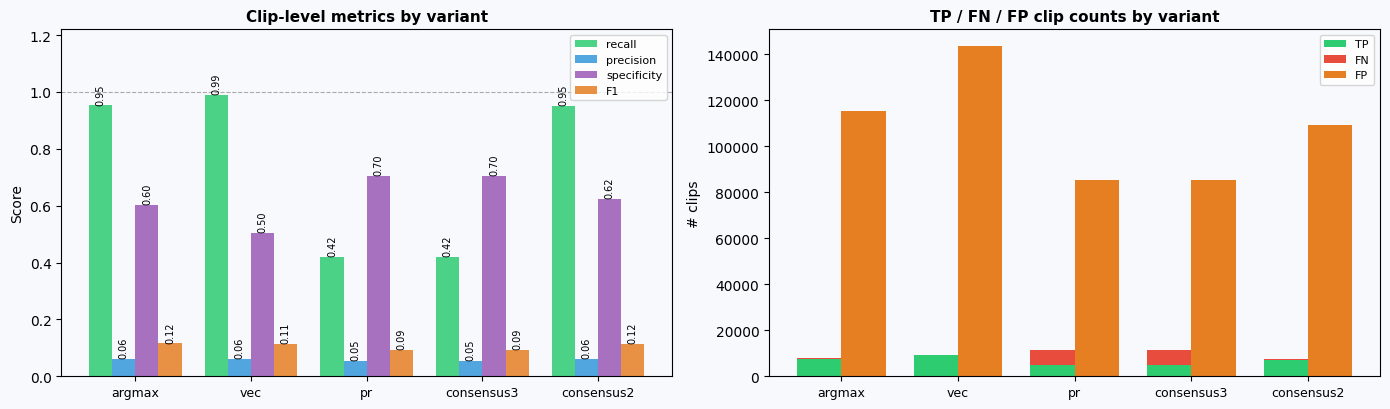

In [9]:
# ── C. Metric comparison across the five variants ─────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

cm = clip_metrics.reset_index()
x = np.arange(len(cm)); w = 0.2

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
fig.patch.set_facecolor('#f7f9fc')

ax = axes[0]
for i, (metric, color) in enumerate([('recall','#2ecc71'), ('precision','#3498db'),
                                      ('specificity','#9b59b6'), ('F1','#e67e22')]):
    bars = ax.bar(x + i*w, cm[metric].fillna(0), w, label=metric, color=color, alpha=0.85)
    for bar, val in zip(bars, cm[metric]):
        if not np.isnan(val):
            ax.text(bar.get_x()+bar.get_width()/2, val+0.01, f'{val:.2f}',
                    ha='center', fontsize=7, rotation=90)
ax.set_xticks(x + w*1.5); ax.set_xticklabels(cm['variant'], fontsize=9)
ax.set_ylim(0, 1.22); ax.set_ylabel('Score', fontsize=10)
ax.set_title('Clip-level metrics by variant', fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.axhline(1.0, ls='--', lw=0.8, color='#aaa')
ax.set_facecolor('#f7f9fc')

ax = axes[1]
w2 = 0.38
ax.bar(x - w2/2, cm['TP'], w2, label='TP', color='#2ecc71')
ax.bar(x - w2/2, cm['FN'], w2, bottom=cm['TP'], label='FN', color='#e74c3c')
ax.bar(x + w2/2, cm['FP'], w2, label='FP', color='#e67e22')
ax.set_xticks(x); ax.set_xticklabels(cm['variant'], fontsize=9)
ax.set_ylabel('# clips', fontsize=10)
ax.set_title('TP / FN / FP clip counts by variant', fontsize=11, fontweight='bold')
ax.legend(fontsize=8); ax.set_facecolor('#f7f9fc')

plt.tight_layout(); plt.show()

Variant: argmax

Species labels in TP clips (fired inside caught expert-positive intervals):
pred_argmax
Ambig    5397
Tt       1673
Pm        222
Oo        183
Dd         46
Gg         23
Bp         11
Ba          4
Gm          1

Species labels in FP clips (fired in expert-negative intervals):
pred_argmax
Ambig    97890
Tt       11164
Oo        4022
Pm        1464
Dd         685
Sc          98
Gg          67
Bp          35
Ba           9
Gm           7


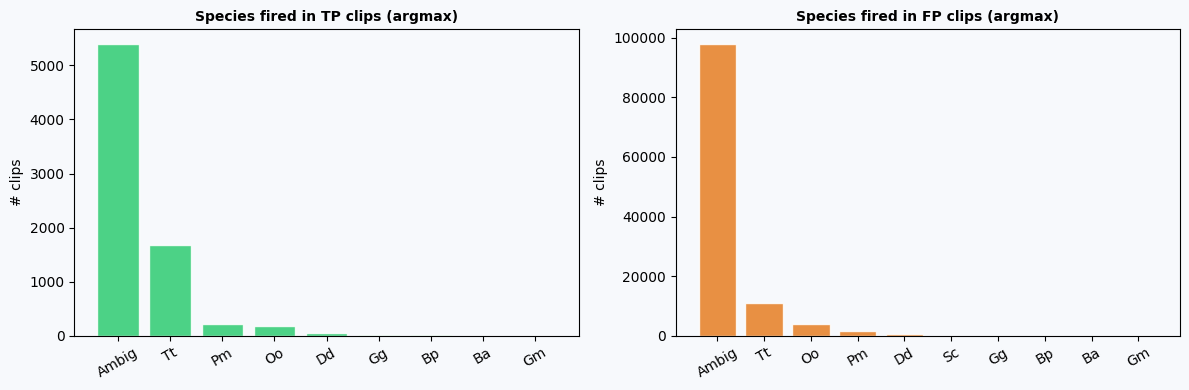

In [10]:
# ── D. Species fired (detection-level; expert only labelled Tt) ───────────────
# The expert labelled only T. truncatus, so per-species verification isn't
# possible. We still inspect WHICH species labels each variant fires, split by
# clip outcome. Shown for argmax (operating point); change `V` to inspect others.
import matplotlib.pyplot as plt

V = 'argmax'   # ← pick any of: argmax, vec, pr, consensus3, consensus2

oc = clips[f'outcome_{V}']
lbl = clips[f'pred_{V}'].map(to_short)

def sp_counts(mask):
    s = lbl[mask]
    s = s[~s.isin(['background', 'uncertain'])]
    return s.value_counts()

tp_sp = sp_counts(oc == 'TP')   # correctly-fired clips in caught positive intervals
fp_sp = sp_counts(oc == 'FP')   # falsely-fired clips in expert-negative intervals

print(f"Variant: {V}")
print("\nSpecies labels in TP clips (fired inside caught expert-positive intervals):")
print(tp_sp.to_string() if len(tp_sp) else '  (none)')
print("\nSpecies labels in FP clips (fired in expert-negative intervals):")
print(fp_sp.to_string() if len(fp_sp) else '  (none)')

if len(tp_sp) + len(fp_sp) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.patch.set_facecolor('#f7f9fc')
    for ax, data, title, color in [
        (axes[0], tp_sp, f'Species fired in TP clips ({V})', '#2ecc71'),
        (axes[1], fp_sp, f'Species fired in FP clips ({V})', '#e67e22'),
    ]:
        if len(data):
            ax.bar(data.index, data.values, color=color, alpha=0.85, edgecolor='white')
            ax.set_ylabel('# clips'); ax.tick_params(axis='x', rotation=30)
        else:
            ax.text(0.5, 0.5, 'none', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_facecolor('#f7f9fc')
    plt.tight_layout(); plt.show()

In [11]:
# ── E. FP / FN deep dive (clip level) ─────────────────────────────────────────
# FP clips: false alarms in expert-negative intervals — how concentrated are they?
# FN clips: clips in fully-missed expert-positive intervals.
V = 'argmax'   # ← change to inspect another variant

oc = clips[f'outcome_{V}']

# FP concentration: firing clips per expert-negative interval
fp_clips = clips[oc == 'FP']
fp_per_ivl = fp_clips.groupby('interval').size()
print(f"Variant: {V}")
print(f"\nFP clips total: {len(fp_clips):,} across {fp_per_ivl.shape[0]:,} expert-negative intervals")
print("FP clips-per-interval distribution:")
print(fp_per_ivl.describe().round(2).to_string() if len(fp_per_ivl) else '  (none)')

# FN: fully-missed expert-positive intervals
fn_clips = clips[oc == 'FN']
fn_intervals = fn_clips['interval'].unique()
print(f"\nFN clips total: {len(fn_clips):,} across {len(fn_intervals):,} fully-missed positive intervals")
if len(fn_intervals):
    print("Missed intervals:", sorted(fn_intervals)[:20])

Variant: argmax

FP clips total: 115,441 across 3,254 expert-negative intervals
FP clips-per-interval distribution:
count    3254.00
mean       35.48
std        25.99
min         1.00
25%        11.00
50%        38.00
75%        47.00
max        94.00

FN clips total: 376 across 8 fully-missed positive intervals
Missed intervals: ['250926045001', '250926183000', '250927043501', '250928024000', '250928185500', '250929024001', '250930112500', '250930114000']


In [12]:
# ── F. Disagreement audit inside missed (FN) intervals ────────────────────────
# In intervals that argmax missed entirely, what did the three base strategies
# actually predict on each clip? Surfaces borderline misses where vec/pr fired
# but argmax didn't (and vice-versa).
V = 'argmax'
fn_intervals = set(clips[clips[f'outcome_{V}'] == 'FN']['interval'])

fn_clip_rows = clips[clips['interval'].isin(fn_intervals)].copy()
# show only clips where at least one base strategy fired something
base_fired = (
    ~fn_clip_rows['pred_argmax'].isin(NON_DETECTION) |
    ~fn_clip_rows['pred_vec'].isin(NON_DETECTION) |
    ~fn_clip_rows['pred_pr'].isin(NON_DETECTION)
)
fn_disagree = fn_clip_rows[base_fired].copy()
fn_disagree['pattern'] = (
    fn_disagree['pred_argmax'].map(to_short) + ' / ' +
    fn_disagree['pred_vec'].map(to_short)    + ' / ' +
    fn_disagree['pred_pr'].map(to_short)
)

print(f"Missed ({V}) intervals: {len(fn_intervals):,}")
print(f"Clips in those intervals where >=1 base strategy fired: {len(fn_disagree):,}")
print("\nTop disagreement patterns (argmax / vec / pr):")
print(fn_disagree['pattern'].value_counts().head(15).to_string()
      if len(fn_disagree) else '  (none — all strategies silent in missed intervals)')

Missed (argmax) intervals: 8
Clips in those intervals where >=1 base strategy fired: 23

Top disagreement patterns (argmax / vec / pr):
pattern
bg / Ambig / bg    13
bg / Oo / bg        7
bg / Sc / bg        2
bg / Pm / bg        1
